Import libraries

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import os


Set Path

In [7]:
#load data
path = '/Users/mac/Desktop/kdd_ml_project'
data_path = os.path.join(path, 'database')
os.listdir(path)
os.listdir(data_path)

['.DS_Store',
 'sampleSubmission.csv',
 'donations.csv',
 'resources.csv',
 'outcomes.csv',
 'essays.csv',
 'projects.csv']

# Feature Engineering

## Dataset1: outcomes

`is_exciting` - ground truth of whether a project is exciting from business perspective  
`at_least_1_teacher_referred_donor` - teacher referred = donor donated because teacher shared a link or publicized their page  
`fully_funded` - project was successfully completed  
`at_least_1_green_donation` - a green donation is a donation made with credit card, PayPal, Amazon or check  
`great_chat` - project has a comment thread with greater than average unique comments  
`three_or_more_non_teacher_referred_donors` - non-teacher referred is a donor that landed on the site by means other than a teacher referral link/page  
`one_non_teacher_referred_donor_giving_100_plus` - see above  
`donation_from_thoughtful_donor` - a curated list of ~15 donors that are power donors and picky choosers (we trust them selecting great projects)  
`great_messages_proportion` -  how great_chat is calculated. proportion of comments on the project page that are unique. If > avg (currently 62%) then great_chat = True  
`teacher_referred_count` - number of donors that were teacher referred (see above)  
`non_teacher_referred_count` - number of donors that were non-teacher referred (see above)  

In [12]:
outcomes = pd.read_csv(os.path.join(data_path, 'outcomes.csv'))
outcomes.to_parquet(os.path.join(data_path, 'outcomes.parquet'))
outcomes = pd.read_parquet(os.path.join(data_path, 'outcomes.parquet'))
outcomes.head()
outcomes.info()
outcomes.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619326 entries, 0 to 619325
Data columns (total 12 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   projectid                                       619326 non-null  object 
 1   is_exciting                                     619326 non-null  object 
 2   at_least_1_teacher_referred_donor               524928 non-null  object 
 3   fully_funded                                    619326 non-null  object 
 4   at_least_1_green_donation                       524928 non-null  object 
 5   great_chat                                      619326 non-null  object 
 6   three_or_more_non_teacher_referred_donors       524928 non-null  object 
 7   one_non_teacher_referred_donor_giving_100_plus  524928 non-null  object 
 8   donation_from_thoughtful_donor                  524928 non-null  object 
 9   great_messages_proportion 

,great_messages_proportion,teacher_referred_count,non_teacher_referred_count
count,439487.00000,524928.000000,524928.000000
mean,52.92709,0.777339,4.361290
std,35.71410,2.227933,5.668748
min,0.00000,0.000000,0.000000
25%,25.00000,0.000000,1.000000
50%,50.00000,0.000000,3.000000
75%,83.00000,0.000000,5.000000
max,100.00000,151.000000,304.000000


In [ ]:
# Feature Engineering

outcomes.replace({'is_exciting': {'t': 1, 'f': 0}}, inplace=True)
outcomes.replace({'fully_funded': {'t': 1, 'f': 0}}, inplace=True)
outcomes.replace({'at_least_1_teacher_referred_donor': {'t': 1, 'f': 0}}, inplace=True)
outcomes.replace({'at_least_1_green_donation': {'t': 1, 'f': 0}}, inplace=True)
outcomes.replace({'great_chat': {'t': 1, 'f': 0}}, inplace=True)
outcomes.replace({'three_or_more_non_teacher_referred_donors': {'t': 1, 'f': 0}}, inplace=True)
outcomes.replace({'one_non_teacher_referred_donor_giving_100_plus': {'t': 1, 'f': 0}}, inplace=True)
outcomes.replace({'donation_from_thoughtful_donor': {'t': 1, 'f': 0}}, inplace=True)

outcomes.isnull().sum()


,projectid,is_exciting,at_least_1_teacher_referred_donor,fully_funded,at_least_1_green_donation,great_chat,three_or_more_non_teacher_referred_donors,one_non_teacher_referred_donor_giving_100_plus,donation_from_thoughtful_donor,great_messages_proportion,teacher_referred_count,non_teacher_referred_count
0,ffffc4f85b60efc5b52347df489d0238,f,None,f,None,f,None,None,None,NaN,NaN,NaN
1,ffffac55ee02a49d1abc87ba6fc61135,f,f,t,t,f,t,f,f,57.0,0.0,7.0


/var/folders/8g/fjg76_9d66jffp3b0xnmcfyh0000gn/T/ipykernel_72690/7418073.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  outcomes.replace({'is_exciting': {'t': 1, 'f': 0}}, inplace=True)
/var/folders/8g/fjg76_9d66jffp3b0xnmcfyh0000gn/T/ipykernel_72690/7418073.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  outcomes.replace({'fully_funded': {'t': 1, 'f': 0}}, inplace=True)
/var/folders/8g/fjg76_9d66jffp3b0xnmcfyh0000gn/T/ipykernel_72690/7418073.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be

projectid                                              0
is_exciting                                            0
at_least_1_teacher_referred_donor                  94398
fully_funded                                           0
at_least_1_green_donation                          94398
great_chat                                             0
three_or_more_non_teacher_referred_donors          94398
one_non_teacher_referred_donor_giving_100_plus     94398
donation_from_thoughtful_donor                     94398
great_messages_proportion                         179839
teacher_referred_count                             94398
non_teacher_referred_count                         94398
dtype: int64

In [21]:
outcomes['fully_funded'].value_counts()
full_y = outcomes.loc[:,['projectid','fully_funded']].set_index('projectid')
full_x = outcomes.loc[:,outcomes.columns != 'fully_funded'].set_index('projectid')

full_y.to_parquet(os.path.join(data_path, 'full_y.parquet'))
full_x.to_parquet(os.path.join(data_path, 'full_x_outcomes.parquet'))


## Dataset2: donations

In [ ]:
donations = pd.read_csv(os.path.join(data_path, 'donations.csv'))
donations.to_parquet(os.path.join(data_path, 'donations.parquet'))
donations = pd.read_parquet(os.path.join(data_path, 'donations.parquet'))
donations.head()
donations.info()
donations.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3097989 entries, 0 to 3097988
Data columns (total 21 columns):
 #   Column                                    Dtype  
---  ------                                    -----  
 0   donationid                                object 
 1   projectid                                 object 
 2   donor_acctid                              object 
 3   donor_city                                object 
 4   donor_state                               object 
 5   donor_zip                                 float64
 6   is_teacher_acct                           object 
 7   donation_timestamp                        object 
 8   donation_to_project                       float64
 9   donation_optional_support                 float64
 10  donation_total                            float64
 11  dollar_amount                             object 
 12  donation_included_optional_support        object 
 13  payment_method                            object 
 14  pa

,donor_zip,donation_to_project,donation_optional_support,donation_total
count,1.385927e+06,3.097989e+06,3.097989e+06,3.097989e+06
mean,5.066494e+04,6.594590e+01,1.073131e+01,7.667691e+01
std,3.331468e+04,2.379026e+02,3.688343e+01,2.704941e+02
min,0.000000e+00,-1.275000e+01,-2.250000e+00,-1.500000e+01
25%,2.000300e+04,1.000000e+01,1.500000e+00,1.000000e+01
50%,4.671400e+04,2.125000e+01,3.750000e+00,2.500000e+01
75%,8.952100e+04,5.000000e+01,7.500000e+00,5.611000e+01
max,9.999900e+04,1.472040e+05,2.199600e+04,1.692000e+05


In [ ]:
display(donations.head(2))
# transform the data type according to the description
donations['donor_zip'] = donations['donor_zip'].astype(str)
donations['is_teacher_acct'].replace({'t': 1, 'f': 0}, inplace=True)
donations['donation_included_optional_support'].replace({'t': 1, 'f': 0}, inplace=True)
donations['payment_included_acct_credit'].replace({'t': 1, 'f': 0}, inplace=True)
donations['payment_included_campaign_gift_card'].replace({'t': 1, 'f': 0}, inplace=True)
donations['payment_included_web_purchased_gift_card'].replace({'t': 1, 'f': 0}, inplace=True)
donations['payment_was_promo_matched'].replace({'t': 1, 'f': 0}, inplace=True)
donations['via_giving_page'].replace({'t': 1, 'f': 0}, inplace=True)
donations['for_honoree'].replace({'t': 1, 'f': 0}, inplace=True)

# create a column with 1 if the donation has a comment, 0 otherwise
donations['with_comment'] = donations['donation_message'].notna().astype(int)

,donationid,projectid,donor_acctid,donor_city,donor_state,donor_zip,is_teacher_acct,donation_timestamp,donation_to_project,donation_optional_support,...,dollar_amount,donation_included_optional_support,payment_method,payment_included_acct_credit,payment_included_campaign_gift_card,payment_included_web_purchased_gift_card,payment_was_promo_matched,via_giving_page,for_honoree,donation_message
0,431d720bc3dfd75ae445a5eaa0b0638d,ffffac55ee02a49d1abc87ba6fc61135,22cbc920c9b5fa08dfb331422f5926b5,Peachtree City,GA,30269.0,f,2011-08-25 14:27:34.807,42.50,7.50,...,10_to_100,t,no_cash_received,f,t,f,f,f,f,I gave to this project because I support the e...
1,fcfedba1c8a0ba77d280cace80a909f6,ffffac55ee02a49d1abc87ba6fc61135,521f1830a77c9dbbf8119d99c6206a16,None,GA,NaN,f,2011-11-04 07:54:21.552,26.83,4.73,...,10_to_100,t,creditcard,f,t,f,f,f,f,I donated because I want to support kids in Ge...


/var/folders/8g/fjg76_9d66jffp3b0xnmcfyh0000gn/T/ipykernel_72690/2768133743.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  donations['is_teacher_acct'].replace({'t': 1, 'f': 0}, inplace=True)
/var/folders/8g/fjg76_9d66jffp3b0xnmcfyh0000gn/T/ipykernel_72690/2768133743.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silen

In [ ]:
# one-hot encoding for payment_method
donations['payment_method'].value_counts()
payment_method_dummies = pd.get_dummies(donations['payment_method'], prefix='payment')
donations = pd.concat([donations, payment_method_dummies], axis=1)

In [64]:
# 将 donation_timestamp 转换为 datetime 类型
donations['donation_timestamp'] = donations['donation_timestamp'].apply(
    lambda x: x.split('.')[0] if '.' in str(x) else x
)
donations['donation_timestamp'] = pd.to_datetime(donations['donation_timestamp'])

In [65]:
donations['dollar_amount'].value_counts()

amount_order = {
    'under_10': 0,
    '10_to_100': 1,
    '100_and_up': 2
}
donations['dollar_amount_encoded'] = donations['dollar_amount'].map(amount_order)

In [90]:
print("Missing values by donation:")
display(donations.isnull().sum()/len(donations))
print("\nMissing message by project (using apply):")
missing_by_project_message = (
    donations[['projectid', 'donation_message']]
    .groupby('projectid')
    .apply(lambda x: (x['donation_message'].isnull().sum()/len(x) * 100).round(2))
    .reset_index(name='missing_percentage')
)
print(missing_by_project_message)

Missing values by donation:


donationid                                  0.000000
projectid                                   0.000000
donor_acctid                                0.000000
donor_city                                  0.647402
donor_state                                 0.194678
donor_zip                                   0.000000
is_teacher_acct                             0.000000
donation_timestamp                          0.000000
donation_to_project                         0.000000
donation_optional_support                   0.000000
donation_total                              0.000000
dollar_amount                               0.000000
donation_included_optional_support          0.000000
payment_method                              0.000000
payment_included_acct_credit                0.000000
payment_included_campaign_gift_card         0.000000
payment_included_web_purchased_gift_card    0.000000
payment_was_promo_matched                   0.000000
via_giving_page                             0.


Missing message by project (using apply):
                               projectid  missing_percentage
0       00001ccc0e81598c4bd86bacb94d7acb                0.00
1       00002bff514104264a6b798356fdd893                0.00
2       00002d691c05c51a5fdfbb2baef0ba25               40.00
3       0000b38bbc7252972f7984848cf58098                0.00
4       0000ee613c92ddc5298bf63142996a5c               66.67
...                                  ...                 ...
525037  fffeebf4827d745aa36b17c2d38d1966                0.00
525038  ffff2d9c769c8fb5335e949c615425eb                0.00
525039  ffff418bb42fad24347527ad96100f81                0.00
525040  ffff97ed93720407d70a2787475932b0                0.00
525041  ffffac55ee02a49d1abc87ba6fc61135                0.00

[525042 rows x 2 columns]


/var/folders/8g/fjg76_9d66jffp3b0xnmcfyh0000gn/T/ipykernel_72690/1472438042.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['donation_message'].isnull().sum()/len(x) * 100).round(2))


In [ ]:
donations_agg = full_x_donations.groupby('projectid').agg({
    'donation_to_project': ['sum', 'count', 'mean'],
    'donation_total': 'mean',
    'is_teacher_acct': 'mean',  # 计算教师账户数量
    'via_giving_page':'mean'
})

# 重命名列
donations_agg.columns = ['_'.join(col).strip() for col in donations_agg.columns.values]


x_donations_agg = donations_agg.reset_index()
x_donations_agg.to_parquet(os.path.join(data_path, 'x_donations_agg.parquet'))

donations.agg = pd.read_parquet(os.path.join(data_path, 'x_donations_agg.parquet'))
donations_agg.info()


In [67]:

full_x_donations = donations.set_index('donationid')
full_x_donations.drop_duplicates(inplace=True)
full_x_donations.to_parquet(os.path.join(data_path, 'full_x_donations.parquet'))



In [ ]:
donations_agg = full_x_donations.groupby('projectid').agg({
    'donation_to_project': ['sum', 'count', 'mean'],
    'donation_total': 'mean',
    'is_teacher_acct': 'mean', 
    'via_giving_page':'mean'
})

donations_agg.columns = ['_'.join(col).strip() for col in donations_agg.columns.values]


x_donations_agg = donations_agg.reset_index()
x_donations_agg.to_parquet(os.path.join(data_path, 'x_donations_agg.parquet'))

donations.agg = pd.read_parquet(os.path.join(data_path, 'x_donations_agg.parquet'))
donations_agg.info()


# Machine Learning

## Load Data

In [81]:
full_x_outcomes = pd.read_parquet(os.path.join(data_path, 'full_x_outcomes.parquet'))
X = pd.concat([full_x_outcomes, donations_agg], axis=1)
y = pd.read_parquet(os.path.join(data_path, 'full_y.parquet'))

## Random Forest

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]


print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     37875
           1       0.97      0.99      0.98     85991

    accuracy                           0.97    123866
   macro avg       0.98      0.96      0.97    123866
weighted avg       0.97      0.97      0.97    123866


Confusion Matrix:
[[35298  2577]
 [  633 85358]]

ROC AUC Score: 0.9879313874009304


Explained variance ratio:
[0.21387327 0.15695126 0.115703   0.10313676 0.07123727 0.06249905
 0.05809113 0.05132013 0.04251792 0.037225  ]


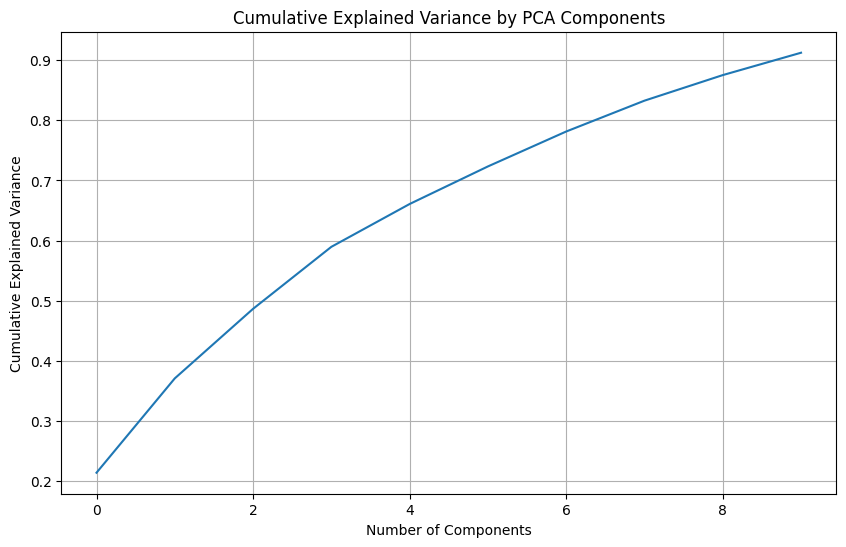

In [94]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer



imputer = SimpleImputer(strategy='mean') 
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.show()
